**Name:** Mohammad Tuhin

**Registration Email:** md.tuhin42525@gmail.com

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [161]:
df = pd.read_csv('titanic_data_updated.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Question 1**

In [162]:

df.shape

print(f"Total potential features: {df.shape[1]}")
print(f"Total sample data: {df.shape[0]}")

df.head(10)



Total potential features: 12
Total sample data: 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [163]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
580,581,yes,second,"Christy, Miss. Julie Rachel",female,25.0,1,1,237789,30.0000,NaN,S
464,465,no,third,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.0500,NaN,S
475,476,no,first,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S
275,276,yes,first,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
285,286,no,third,"Stankovic, Mr. Ivan",male,33.0,0,0,349239,8.6625,NaN,C


**Question 2**

In [164]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [165]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

**Question 3**

In [166]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [167]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


**2 observations**

1. The Age column contains missing values because its count is lower than the total number of rows.

2. The Fare column has a large standard deviation which indicates high variation in ticket prices.

**Question 4**

<Axes: xlabel='Survived', ylabel='count'>

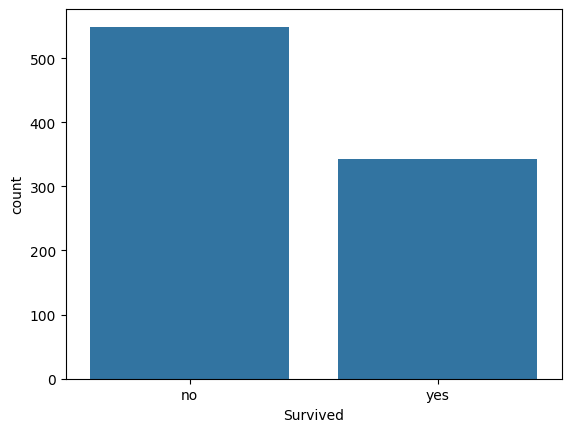

In [168]:

sns.countplot(data = df, x=df['Survived'])

In [169]:
(df['Survived'].value_counts() / len(df)) * 100

,count
Survived,
no,61.616162
yes,38.383838


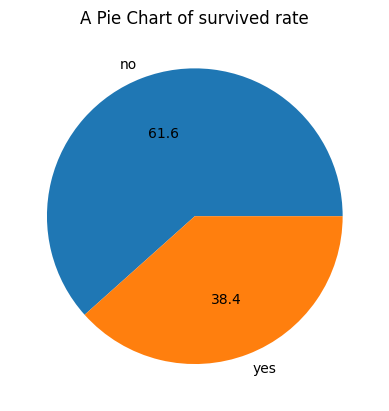

In [170]:
survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()

plt.pie(survived_count, labels=survived_label, autopct="%1.1f")
plt.title("A Pie Chart of survived rate")
plt.show()

**2 insights from the analysis.**

1. The number of passenger who did not survive is higher than the number of survivors.

2. Around 38.8% of passenger srvived, while about 61.6% did not survive.

**Question 5**

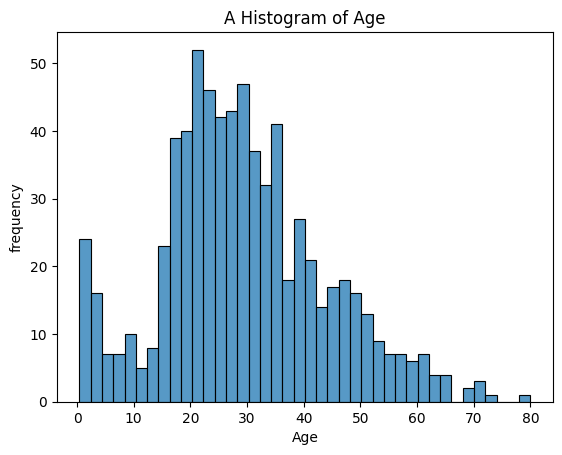

In [171]:

sns.histplot(df['Age'], bins=40)

plt.title("A Histogram of Age")
plt.xlabel("Age")
plt.ylabel("frequency")
plt.show()

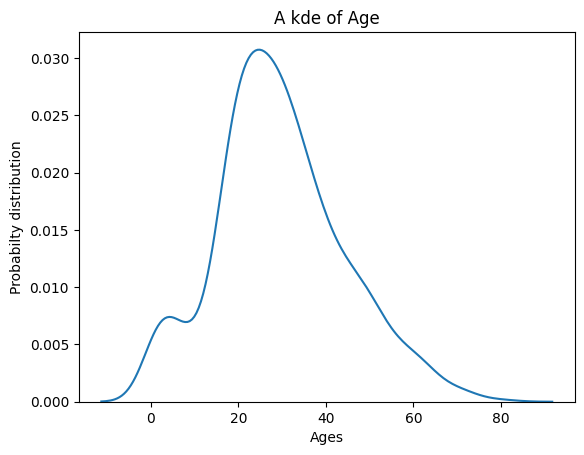

In [172]:
sns.kdeplot(df['Age'])

plt.title("A kde of Age")
plt.xlabel("Ages")
plt.ylabel("Probabilty distribution")
plt.show()

**2 observations from the plots.**

1. Most passengers were between 20 and 40 years old.

2. The distribution is slightly right skewed because there are fewer old passengers with higher ages.

**Question 6**

<Axes: xlabel='Sex', ylabel='count'>

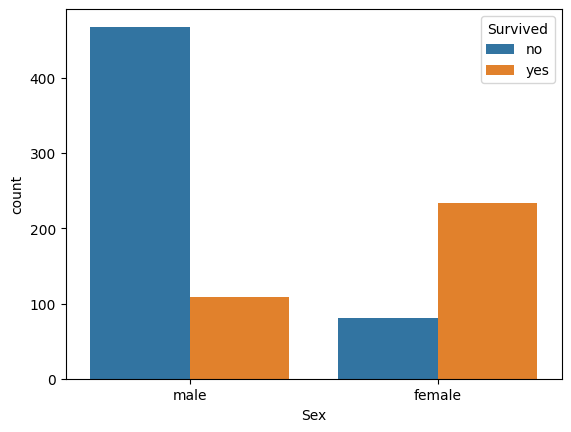

In [173]:
sns.countplot(x = df['Sex'], hue=df['Survived'])

In [174]:
survived_ratio = df.groupby('Sex') ['Survived'].value_counts(normalize=True)

print(survived_ratio)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


**2 insights from the analysis.**

1. Female passenger had a much higher survival rate compared to male passengers.

2. Most male passengers did not survive, while the majority of female passengers survived.


**Question 7**

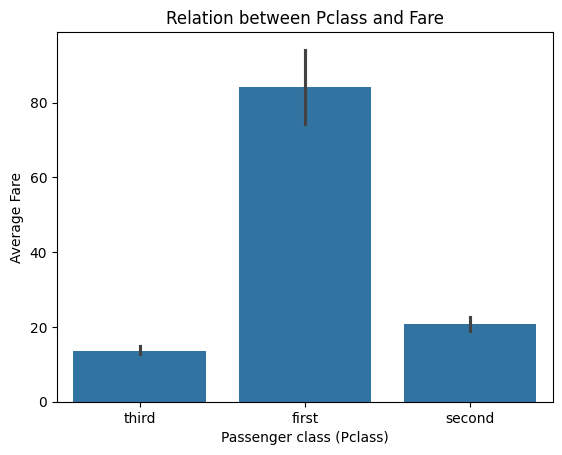

In [175]:
sns.barplot(data = df, x='Pclass', y='Fare')

plt.title("Relation between Pclass and Fare")
plt.xlabel("Passenger class (Pclass)")
plt.ylabel("Average Fare")
plt.show()

**2 observations from the visualization.**

1. First class passengers paid the highest average fare among all passenger classes.

2. The average fare decreases as passenger class changes from 1st class to 3rd class.

**Question 8**

<Axes: xlabel='Age', ylabel='Density'>

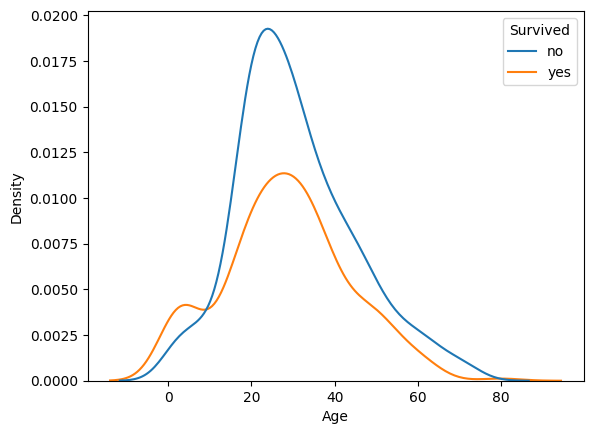

In [176]:
sns.kdeplot(data = df, x='Age', hue='Survived')

**2 insights from the graph.**

1. Younger passenger had a relatively higher survival probability compared to older passengers.

2. Non-survived passengers were more concentrated in the young adult age range around 20-35 years.

**Question 9**

In [177]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [178]:
df.isnull().sum()

# df.drop(['Cabin'], axis=1, inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [179]:
X = df.drop(['Survived'], axis=1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [180]:
y = df['Survived']

y

,Survived
0,no
1,yes
2,yes
3,yes
4,no
...,...
886,no
887,yes
888,no
889,yes


In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [182]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (712, 8)
Shape of X_test:  (179, 8)
Shape of y_train:  (712,)
Shape of y_test:  (179,)


**Question 10**

In [183]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']])
X_test['Age'] = age_imputer.transform(X_test[['Age']])

In [184]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(X_train[['Embarked']])

X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel

In [185]:

X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,0


In [186]:
cabin_emputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)
cabin_emputer.fit(X_train[['Cabin']])

X_train[['Cabin', 'cabin_missing_indicator']] = cabin_emputer.transform(X_train[['Cabin']])
X_test[['Cabin', 'cabin_missing_indicator']] = cabin_emputer.transform(X_test[['Cabin']])

In [187]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [188]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0


In [189]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0
